# Background Estimation (`photutils.background`)

## Introduction

To accurately measure the <u>photometry and morphological</u> properties of astronomical sources, one requires an accurate estimate of the background, which can be from both the sky and the detector. Similarly, having an accurate estimate of the background noise is important for determining the significance of source detections and for estimating photometric errors.

Unfortunately, accurate background and background noise estimation is a <u>difficult task.</u> Further, because astronomical images can cover a wide variety of scenes, there is not a single background estimation method that will always be applicable. Photutils provides tools for estimating the background and background noise in your data, but they will likely require some tweaking to optimize the background estimate for your data.

## Scalar Background and Noise Estimation

### Simple Statistics

If the background level and noise are relatively constant across an image, the simplest way to estimate these values is to derive scalar quantities using simple approximations. When computing the image statistics one must take into account the astronomical sources present in the images, which add a positive tail to the distribution of pixel intensities. For example, one may consider using the image median as the background level and the image standard deviation as the 1-sigma background noise, but the resulting values are biased by the presence of real sources.

A slightly better method involves using statistics that are robust against the presence of outliers, such as the biweight location for the background level and biweight scale or normalized [median absolute deviation (MAD)](https://en.wikipedia.org/wiki/Median_absolute_deviation) for the background noise estimation. However, for most astronomical scenes these methods will also be biased by the presence of astronomical sources in the image.

As an example, we load a synthetic image comprised of 100 sources with a Gaussian-distributed background whose mean is 5 and standard deviation is 2:

In [4]:
from photutils.datasets import make_100gaussians_image 
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

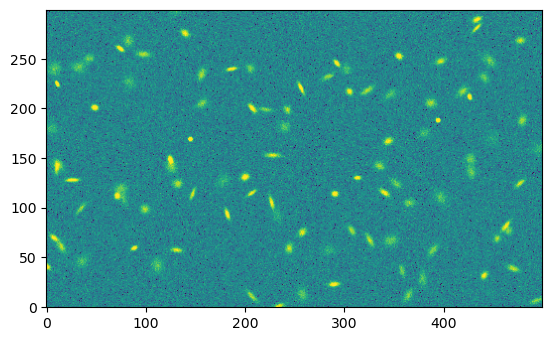

In [5]:
data = make_100gaussians_image()
    # Executa a função e armazena a imagem gerada em um array NumPy 2D chamado data.
    # A imagem tem dimensões padrão (geralmente 512×512 pixels) e contém as 100 fontes gaussianas mais um fundo com ruído.

norm = simple_norm(data, 'sqrt', percent=99.5)
fig, ax = plt.subplots()
ax.imshow(data, norm=norm, origin='lower')